In [1]:
import pulp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# mathematical_optimization_using_python/data/3.school/students.csv
s_df =pd.read_csv('/home/jovyan/data/3.school/students.csv')
s_df.head()

,student_id,gender,leader_flag,support_flag,score
0,1,0,0,0,335
1,2,1,0,0,379
2,3,0,0,0,350
3,4,0,0,0,301
4,5,1,0,0,317


In [3]:
s_df['gender'].value_counts()

gender
0    160
1    158
Name: count, dtype: int64

In [4]:
s_df['score'].describe()

count    318.000000
mean     303.644654
std       65.179995
min       88.000000
25%      261.000000
50%      310.000000
75%      350.000000
max      485.000000
Name: score, dtype: float64

<Axes: >

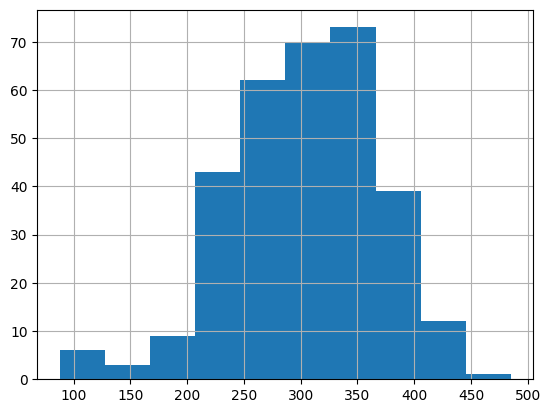

In [5]:
s_df['score'].hist()

In [6]:
s_df['leader_flag'].value_counts()

leader_flag
0    301
1     17
Name: count, dtype: int64

In [7]:
s_df['support_flag'].value_counts()

support_flag
0    314
1      4
Name: count, dtype: int64

In [8]:
s_pair_df = pd.read_csv('/home/jovyan/data/3.school/student_pairs.csv')
s_pair_df.head()

,student_id1,student_id2
0,118,189
1,72,50
2,314,233


In [9]:
prob = pulp.LpProblem('ClassAssignmentProblem', pulp.LpMaximize)

In [10]:
S = s_df['student_id'].tolist()

In [11]:
C = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']

In [12]:
SC = [(s, c) for s in S for c in C]

x = pulp.LpVariable.dicts('x', SC, cat='Binary')

In [13]:
for s in S:
    prob += pulp.lpSum(x[s, c] for c in C) == 1

In [14]:
for c in C:
    prob += pulp.lpSum(x[s, c] for s in S) >= 39
    prob += pulp.lpSum(x[s, c] for s in S) <= 40

In [15]:
S_male = [row.student_id for row in s_df.itertuples() if row.gender == 1]
S_female = [row.student_id for row in s_df.itertuples() if row.gender == 0]

for c in C:
    prob += pulp.lpSum([x[s, c] for s in S_male]) <= 20
    prob += pulp.lpSum([x[s, c] for s in S_female]) <= 20

In [16]:
score = {row.student_id: row.score for row in s_df.itertuples()}

score_mean = s_df['score'].mean()

for c in C:
    prob += (score_mean - 10) * pulp.lpSum(x[s, c] for s in S) <= pulp.lpSum(x[s, c] * score[s] for s in S)
    prob += pulp.lpSum(x[s, c] * score[s] for s in S) <= (score_mean + 10) * pulp.lpSum(x[s, c] for s in S)

In [17]:
S_leader = [row.student_id for row in s_df.itertuples() if row.leader_flag == 1]

for c in C:
    prob += pulp.lpSum(x[s, c] for s in S_leader) >= 2

In [18]:
S_support = [row.student_id for row in s_df.itertuples() if row.support_flag == 1]

for c in C:
    prob += pulp.lpSum(x[s, c] for s in S_support) <= 1

In [19]:
SS = [(row.student_id1, row.student_id2) for row in s_pair_df.itertuples()]

for s1, s2 in SS:
    for c in C:
        prob += x[s1, c] + x[s2, c] <= 1

In [20]:
status = prob.solve()
print(status)
print(pulp.LpStatus[status])

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /opt/conda/lib/python3.11/site-packages/pulp/apis/../solverdir/cbc/linux/i64/cbc /tmp/9643280840b24339a58ac8b4ea5b3551-pulp.mps -max -timeMode elapsed -branch -printingOptions all -solution /tmp/9643280840b24339a58ac8b4ea5b3551-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 411 COLUMNS
At line 20981 RHS
At line 21388 BOUNDS
At line 23934 ENDATA
Problem MODEL has 406 rows, 2545 columns and 15480 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 0 - 0.08 seconds
Cgl0005I 318 SOS with 2544 members
Cgl0004I processed model has 398 rows, 2544 columns (2544 integer (2544 of which binary)) and 12936 elements
Cbc0038I Initial state - 45 integers unsatisfied sum - 10.177
Cbc0038I Solution found of 0
Cbc0038I Before mini branch and bound, 2538 integers at bound fixed and 0 continuous
Cbc0038I Mini bra

In [21]:
C2Ss = {}

for c in C:
    C2Ss[c] = [s for s in S if pulp.value(x[s, c]) == 1]

for c, Ss in C2Ss.items():
    print('Class:', c)
    print('Num:', len(Ss))
    print('Student:', Ss)
    print()

Class: A
Num: 40
Student: [2, 9, 19, 39, 42, 63, 65, 71, 79, 83, 85, 88, 99, 109, 111, 123, 126, 136, 138, 145, 148, 165, 168, 173, 177, 179, 180, 193, 199, 206, 224, 233, 237, 240, 246, 264, 267, 291, 292, 298]

Class: B
Num: 40
Student: [11, 15, 48, 50, 70, 82, 89, 91, 102, 104, 113, 114, 120, 124, 127, 146, 149, 159, 167, 170, 172, 176, 188, 190, 203, 212, 213, 220, 222, 231, 238, 245, 263, 270, 275, 276, 283, 287, 290, 317]

Class: C
Num: 40
Student: [3, 10, 14, 23, 25, 27, 31, 33, 41, 49, 53, 54, 58, 73, 93, 97, 98, 122, 142, 152, 156, 160, 171, 187, 210, 211, 217, 219, 227, 236, 242, 254, 258, 260, 268, 273, 277, 278, 301, 318]

Class: D
Num: 40
Student: [13, 16, 36, 37, 43, 51, 56, 59, 61, 67, 68, 75, 84, 92, 108, 121, 128, 134, 139, 140, 158, 161, 175, 192, 198, 200, 205, 218, 221, 225, 235, 241, 252, 255, 256, 257, 261, 266, 293, 316]

Class: E
Num: 40
Student: [5, 21, 22, 24, 38, 69, 72, 78, 87, 96, 105, 106, 107, 115, 129, 132, 141, 143, 150, 154, 164, 166, 183, 184, 189, 19

In [22]:
for s in S:
    assigned_class = [x[s, c].value() for c in C if x[s, c].value() == 1]
    if len(assigned_class) != 1:
        print('error:', s, assigned_class)

In [23]:
result_df = s_df.copy()

S2C = {s: c for s in S for c in C if x[s, c].value() == 1}

result_df['assigned_class'] = result_df['student_id'].map(S2C)
result_df.head()

,student_id,gender,leader_flag,support_flag,score,assigned_class
0,1,0,0,0,335,F
1,2,1,0,0,379,A
2,3,0,0,0,350,C
3,4,0,0,0,301,G
4,5,1,0,0,317,E


In [24]:
result_df.groupby('assigned_class')['student_id'].count()

assigned_class
A    40
B    40
C    40
D    40
E    40
F    39
G    40
H    39
Name: student_id, dtype: int64

In [25]:
result_df.groupby(['assigned_class', 'gender'])['student_id'].count()

assigned_class  gender
A               0         20
                1         20
B               0         20
                1         20
C               0         20
                1         20
D               0         20
                1         20
E               0         20
                1         20
F               0         20
                1         19
G               0         20
                1         20
H               0         20
                1         19
Name: student_id, dtype: int64

In [26]:
result_df.groupby('assigned_class')['score'].mean()

assigned_class
A    313.400000
B    294.475000
C    312.000000
D    310.500000
E    296.775000
F    295.384615
G    312.250000
H    293.923077
Name: score, dtype: float64

In [27]:
result_df.groupby('assigned_class')['leader_flag'].sum()

assigned_class
A    3
B    2
C    2
D    2
E    2
F    2
G    2
H    2
Name: leader_flag, dtype: int64

In [28]:
result_df.groupby('assigned_class')['support_flag'].sum()

assigned_class
A    0
B    1
C    1
D    0
E    1
F    0
G    1
H    0
Name: support_flag, dtype: int64

In [29]:
for i , (s1, s2) in enumerate(SS):
    print('case:', i)
    c1 = S2C[s1]
    c2 = S2C[s2]
    print('s1 : {}-{}' .format(s1, c1))
    print('s2 : {}-{}' .format(s2, c2))
    print('')

case: 0
s1 : 118-G
s2 : 189-E

case: 1
s1 : 72-E
s2 : 50-B

case: 2
s1 : 314-H
s2 : 233-A



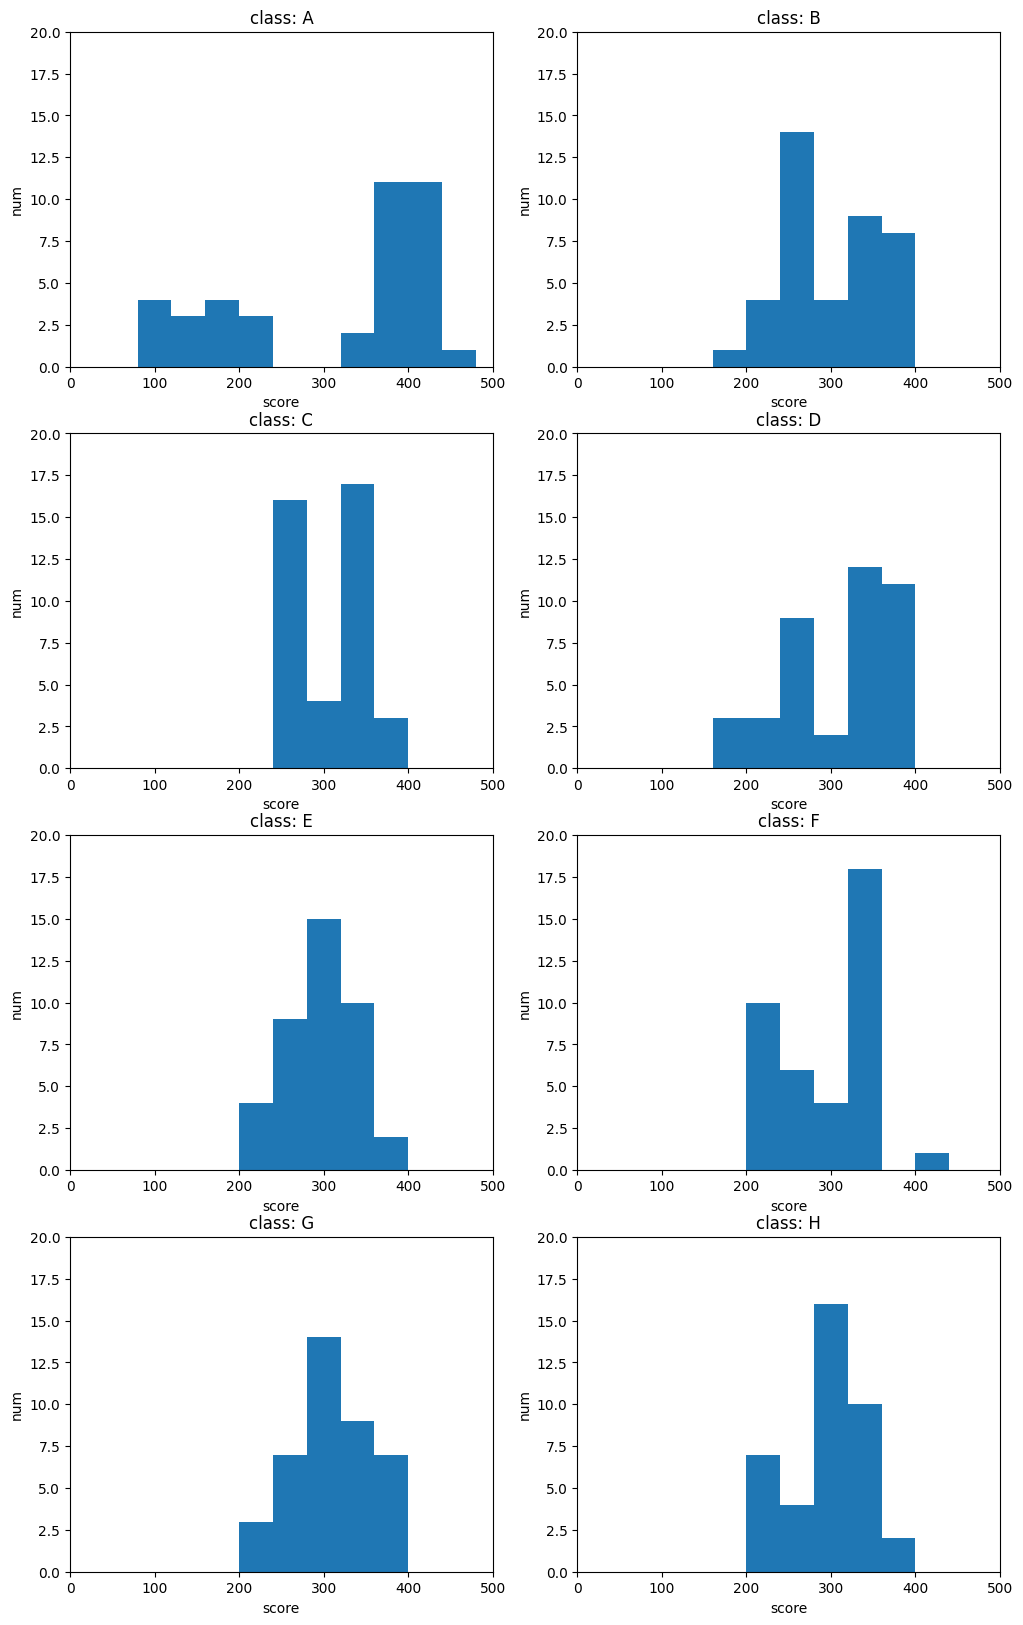

In [31]:
fig = plt.figure(figsize=(12, 20))
for i, c in enumerate(C):
    cls_df = result_df[result_df['assigned_class'] == c]
    ax = fig.add_subplot(4
        ,2
        ,i+1
        ,xlabel='score'
        ,ylabel='num'
        ,xlim=(0, 500)
        ,ylim=(0, 20)
        ,title='class: {}'.format(c)
    )
    ax.hist(cls_df['score'], bins=range(0, 500, 40))


In [32]:
s_df['score_rank'] = s_df['score'].rank(ascending=False, method='first')

class_dic = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H'}
s_df['init_assigned_class'] = s_df['score_rank'].map(lambda x: x % 8).map(class_dic)
s_df.head()

,student_id,gender,leader_flag,support_flag,score,score_rank,init_assigned_class
0,1,0,0,0,335,109.0,F
1,2,1,0,0,379,38.0,G
2,3,0,0,0,350,79.0,H
3,4,0,0,0,301,172.0,E
4,5,1,0,0,317,147.0,D


In [33]:
init_flg = {(s, c): 0 for s in S for c in C}

for row in s_df.itertuples():
    init_flg[row.student_id, row.init_assigned_class] = 1

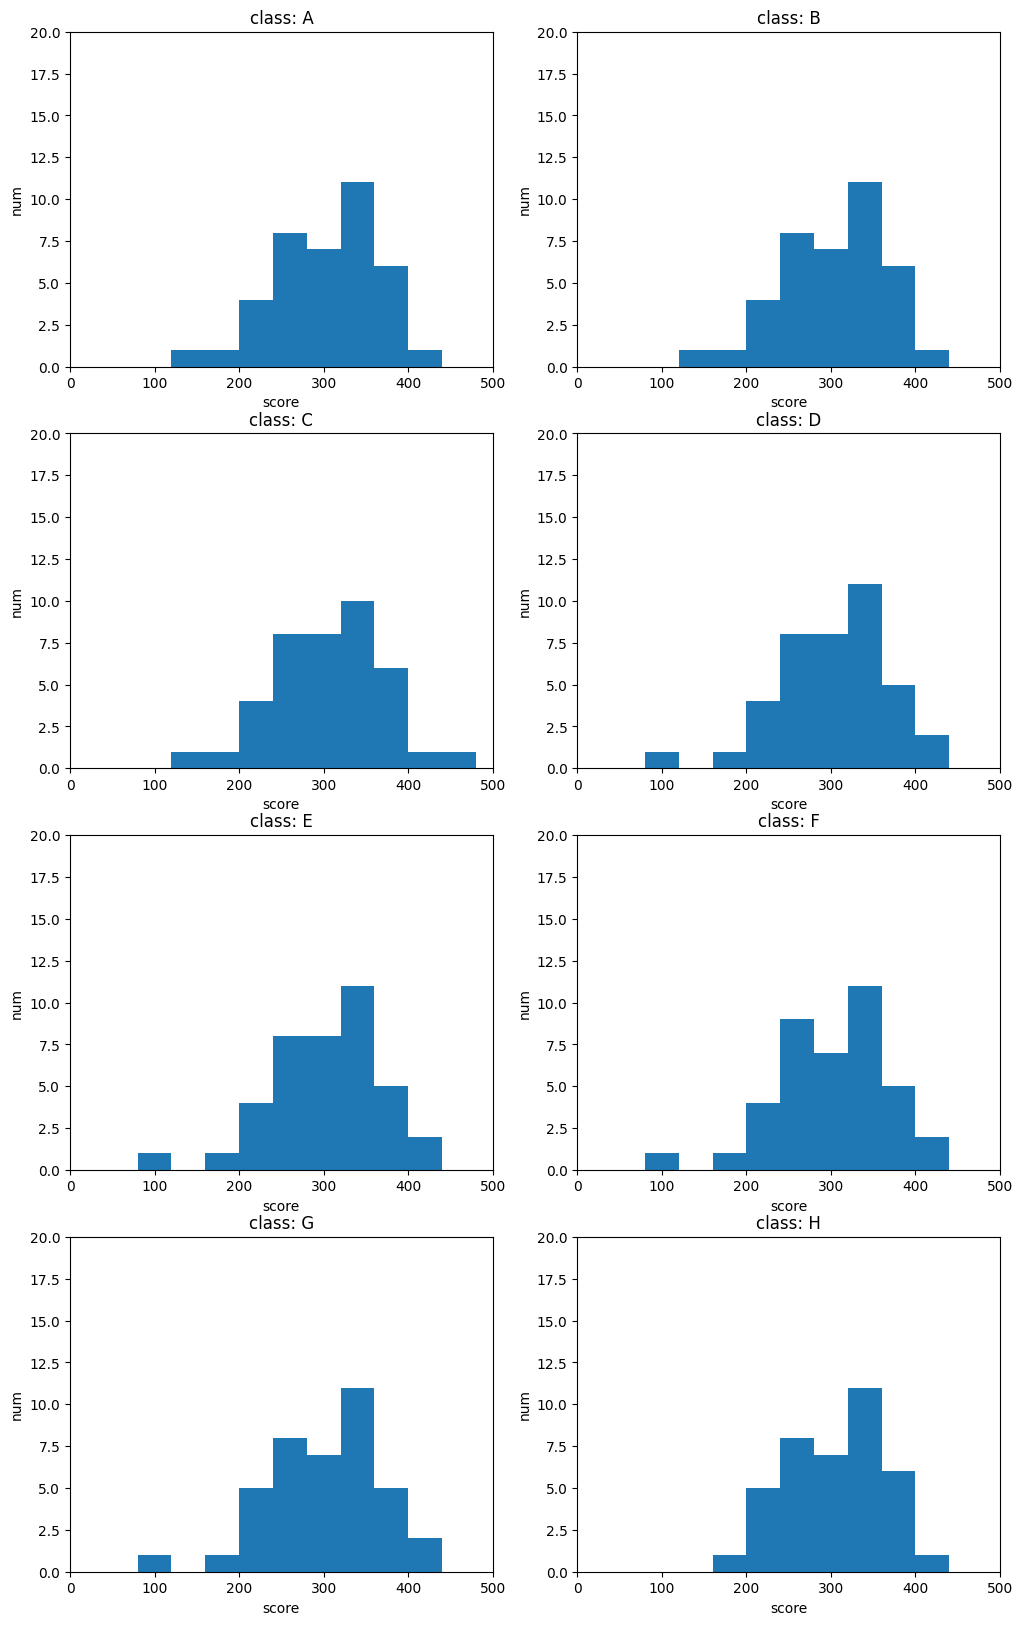

In [36]:
fig = plt.figure(figsize=(12, 20))
for i, c in enumerate(C):
    cls_df = s_df[s_df['init_assigned_class'] == c]
    ax = fig.add_subplot(4
        ,2
        ,i+1
        ,xlabel='score'
        ,ylabel='num'
        ,xlim=(0, 500)
        ,ylim=(0, 20)
        ,title='class: {}'.format(c)
    )
    ax.hist(cls_df['score'], bins=range(0, 500, 40))


In [37]:
prob += pulp.lpSum(x[s, c] * init_flg[s, c] for s in S for c in C)

In [38]:
s_df = pd.read_csv('/home/jovyan/data/3.school/students.csv')
s_pair_df = pd.read_csv('/home/jovyan/data/3.school/student_pairs.csv')

prob = pulp.LpProblem('ClassAssignmentProblem', pulp.LpMaximize)

S = s_df['student_id'].tolist()

SC = [(s, c) for s in S for c in C]

x = pulp.LpVariable.dicts('x', SC, cat='Binary')

for s in S:
    prob += pulp.lpSum(x[s, c] for c in C) == 1

for c in C:
    prob += pulp.lpSum(x[s, c] for s in S) >= 39
    prob += pulp.lpSum(x[s, c] for s in S) <= 40

S_male = [row.student_id for row in s_df.itertuples() if row.gender == 1]

S_female = [row.student_id for row in s_df.itertuples() if row.gender == 0]

for c in C:
    prob += pulp.lpSum([x[s, c] for s in S_male]) <= 20
    prob += pulp.lpSum([x[s, c] for s in S_female]) <= 20

score = {row.student_id: row.score for row in s_df.itertuples()}
score_mean = s_df['score'].mean()

for c in C:
    prob += (score_mean - 10) * pulp.lpSum(x[s, c] for s in S) <= pulp.lpSum(x[s, c] * score[s] for s in S)
    prob += pulp.lpSum(x[s, c] * score[s] for s in S) <= (score_mean + 10) * pulp.lpSum(x[s, c] for s in S) 

S_leader = [row.student_id for row in s_df.itertuples() if row.leader_flag == 1]
for c in C:
    prob += pulp.lpSum(x[s, c] for s in S_leader) >= 2

S_support = [row.student_id for row in s_df.itertuples() if row.support_flag == 1]
for c in C:
    prob += pulp.lpSum(x[s, c] for s in S_support) <= 1

SS = [(row.student_id1, row.student_id2) for row in s_pair_df.itertuples()]

for row in s_pair_df.itertuples():
    s1 = row.student_id1
    s2 = row.student_id2
    for c in C:
        prob += x[s1, c] + x[s2, c] <= 1

s_df['score_rank'] = s_df['score'].rank(ascending=False, method='first')
class_dic = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H'}
s_df['init_assigned_class'] = s_df['score_rank'].map(lambda x: x % 8).map(class_dic)
init_flg = {(s, c): 0 for s in S for c in C}
for row in s_df.itertuples():
    init_flg[row.student_id, row.init_assigned_class] = 1

prob += pulp.lpSum(x[s, c] * init_flg[s, c] for s in S for c in C)

status = prob.solve()
print(status)
print(pulp.LpStatus[status])

C2Ss = {}
for c in C:
    C2Ss[c] = [s for s in S if pulp.value(x[s, c]) == 1]

for c, Ss in C2Ss.items():
    print('Class:', c)
    print('Num:', len(Ss))
    print('Student:', Ss)
    print() 

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /opt/conda/lib/python3.11/site-packages/pulp/apis/../solverdir/cbc/linux/i64/cbc /tmp/9c21e510401442028077b2cc07387ea5-pulp.mps -max -timeMode elapsed -branch -printingOptions all -solution /tmp/9c21e510401442028077b2cc07387ea5-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 411 COLUMNS
At line 21298 RHS
At line 21705 BOUNDS
At line 24250 ENDATA
Problem MODEL has 406 rows, 2544 columns and 15480 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 298 - 0.01 seconds
Cgl0005I 318 SOS with 2544 members
Cgl0004I processed model has 398 rows, 2544 columns (2544 integer (2544 of which binary)) and 12936 elements
Cutoff increment increased from 1e-05 to 0.9999
Cbc0038I Initial state - 0 integers unsatisfied sum - 1.76525e-14
Cbc0038I Solution found of -298
Cbc0038I Before mini branch and bound, 2544 i

In [39]:
result_df2 = s_df.copy()

S2C = {s: c for s in S for c in C if x[s, c].value() == 1}

result_df2['assigned_class'] = result_df2['student_id'].map(S2C)
result_df2.head()

,student_id,gender,leader_flag,support_flag,score,score_rank,init_assigned_class,assigned_class
0,1,0,0,0,335,109.0,F,F
1,2,1,0,0,379,38.0,G,A
2,3,0,0,0,350,79.0,H,H
3,4,0,0,0,301,172.0,E,E
4,5,1,0,0,317,147.0,D,D


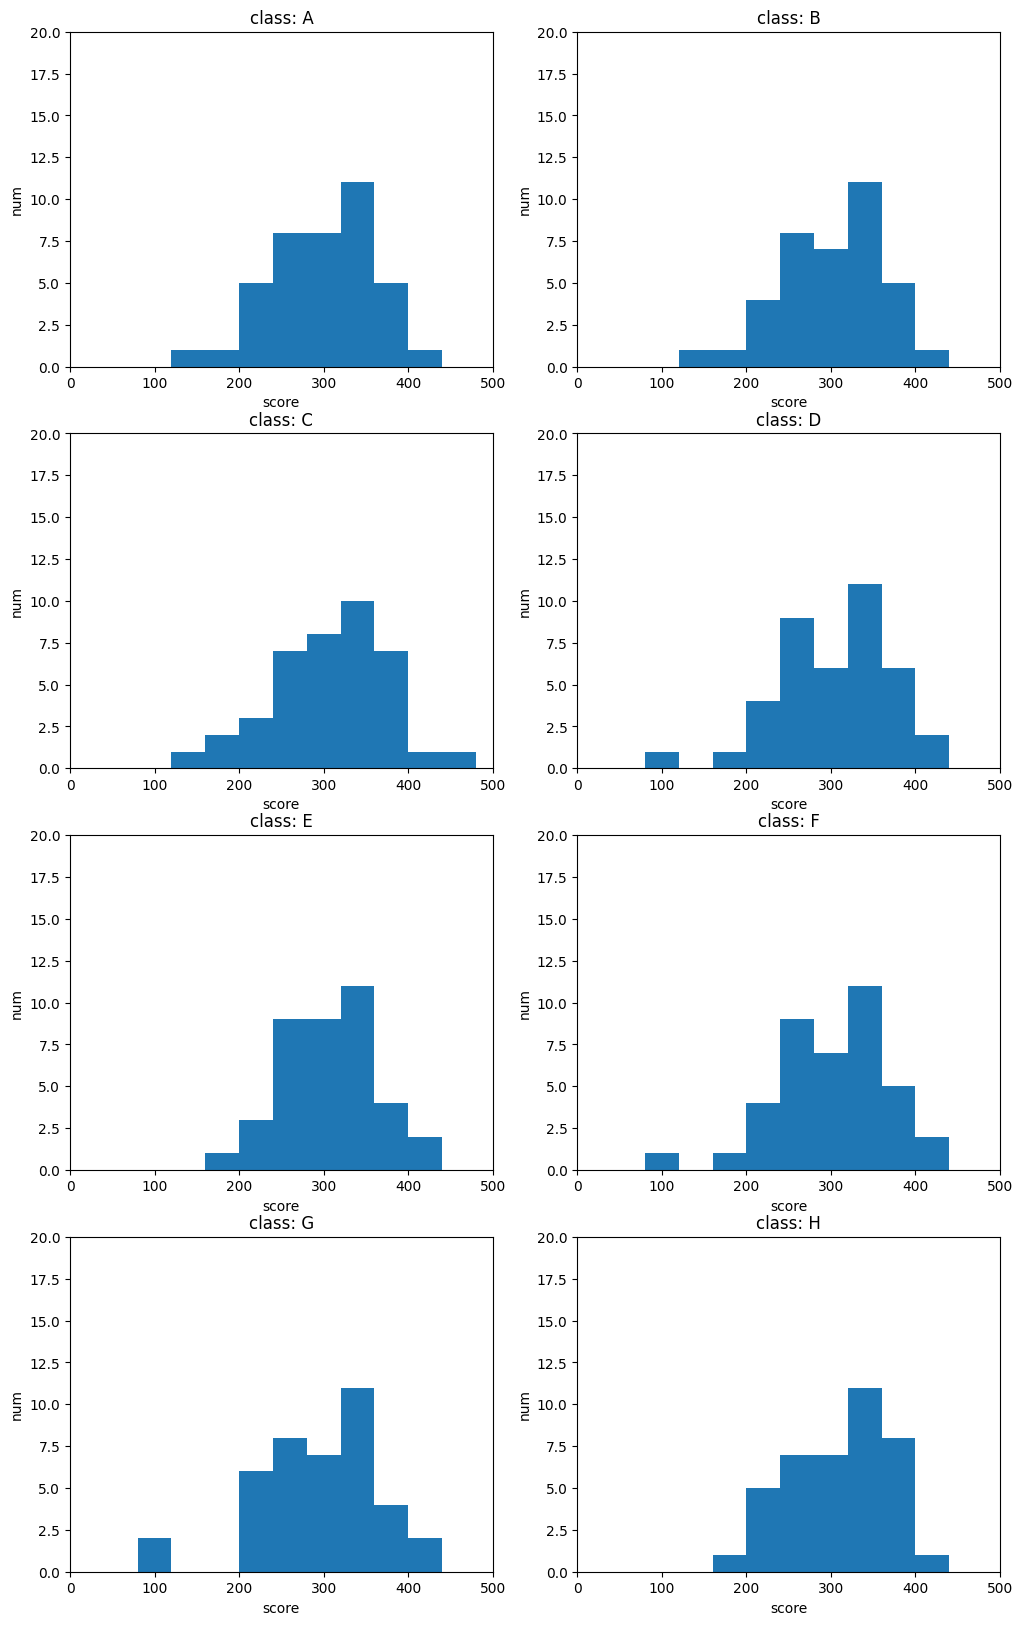

In [40]:
fig = plt.figure(figsize=(12, 20))
for i, c in enumerate(C):
    cls_df = result_df2[result_df2['assigned_class'] == c]
    ax = fig.add_subplot(4
        ,2
        ,i+1
        ,xlabel='score'
        ,ylabel='num'
        ,xlim=(0, 500)
        ,ylim=(0, 20)
        ,title='class: {}'.format(c)
    )
    ax.hist(cls_df['score'], bins=range(0, 500, 40))
